# Name: Sujal Sonawane
# PRN: 202301040131


# Lab Assignment 1 — Neural Network Implementation from Scratch
**Objective:** Implement a feedforward neural network from scratch in Python (no deep learning libraries).

**Architecture:** `Input(2)` → `Hidden Layer(2 neurons)` → `Output(1 neuron)`

**Topics Covered:**
- Forward Pass
- Backpropagation
- Gradient Descent Weight Updates
- Weight display at each Epoch


## Step 1 — Import Libraries
Only `numpy` is used. No deep learning libraries (TensorFlow, PyTorch, Keras, etc.)

In [1]:
import numpy as np

## Step 2 — Activation Function: Sigmoid

The **sigmoid** function maps any real number to the range **(0, 1)**:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

Its **derivative** (used in backpropagation):

$$\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))$$


In [2]:
def sigmoid(x):
    """Sigmoid activation: maps input to (0, 1)"""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Derivative of sigmoid — used in backpropagation"""
    return sigmoid(x) * (1 - sigmoid(x))

# Quick test
print("sigmoid(0)   =", sigmoid(0))       # Expected: 0.5
print("sigmoid(2)   =", round(sigmoid(2), 4))
print("sigmoid'(0)  =", sigmoid_derivative(0))  # Expected: 0.25


sigmoid(0)   = 0.5
sigmoid(2)   = 0.8808
sigmoid'(0)  = 0.25


## Step 3 — Dataset: XOR Problem

| Input 1 | Input 2 | Output |
|---------|---------|--------|
|    0    |    0    |   0    |
|    0    |    1    |   1    |
|    1    |    0    |   1    |
|    1    |    1    |   0    |

> **Why XOR?** It is a non-linear problem — a single neuron cannot solve it. A hidden layer is required, making it a perfect test for a neural network.


In [3]:
# Input features (4 samples, 2 features each)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

# Target labels
y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

print("Input X:\n", X)
print("\nTarget y:\n", y)


Input X:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Target y:
 [[0.]
 [1.]
 [1.]
 [0.]]


## Step 4 — Initialize Weights and Biases

**Network Architecture:**
- **W1** : shape `(2, 2)` — 2 inputs → 2 hidden neurons
- **b1** : shape `(1, 2)` — bias for hidden layer
- **W2** : shape `(2, 1)` — 2 hidden neurons → 1 output
- **b2** : shape `(1, 1)` — bias for output layer

Weights are initialized randomly; biases start at zero.


In [4]:
np.random.seed(42)        # For reproducibility
learning_rate = 0.5

# Hidden layer parameters
W1 = np.random.randn(2, 2)   # shape: (2 inputs  × 2 hidden)
b1 = np.zeros((1, 2))         # shape: (1 × 2 hidden)

# Output layer parameters
W2 = np.random.randn(2, 1)   # shape: (2 hidden × 1 output)
b2 = np.zeros((1, 1))         # shape: (1 × 1 output)

print("Initial W1 (Input → Hidden):\n", W1)
print("\nInitial b1 (Hidden Bias):\n",  b1)
print("\nInitial W2 (Hidden → Output):\n", W2)
print("\nInitial b2 (Output Bias):\n",  b2)


Initial W1 (Input → Hidden):
 [[ 0.49671415 -0.1382643 ]
 [ 0.64768854  1.52302986]]

Initial b1 (Hidden Bias):
 [[0. 0.]]

Initial W2 (Hidden → Output):
 [[-0.23415337]
 [-0.23413696]]

Initial b2 (Output Bias):
 [[0.]]


## Step 5 — Forward Pass

**Hidden Layer:**
$$Z_1 = X \cdot W_1 + b_1$$
$$A_1 = \sigma(Z_1)$$

**Output Layer:**
$$Z_2 = A_1 \cdot W_2 + b_2$$
$$A_2 = \sigma(Z_2)$$

$A_2$ is the final prediction of the network.


In [5]:
def forward_pass(X, W1, b1, W2, b2):
    """
    Perform a forward pass through the network.
    Returns activations and intermediate values needed for backprop.
    """
    # Hidden layer
    Z1 = np.dot(X, W1) + b1      # Linear combination
    A1 = sigmoid(Z1)              # Activation

    # Output layer
    Z2 = np.dot(A1, W2) + b2     # Linear combination
    A2 = sigmoid(Z2)              # Final prediction

    return Z1, A1, Z2, A2

# Test forward pass with initial weights
Z1, A1, Z2, A2 = forward_pass(X, W1, b1, W2, b2)
print("Hidden layer output A1:\n", A1)
print("\nNetwork predictions A2:\n", A2)


Hidden layer output A1:
 [[0.5        0.5       ]
 [0.65648939 0.82098421]
 [0.62168683 0.46548889]
 [0.75848706 0.79975528]]

Network predictions A2:
 [[0.44172968]
 [0.41436683]
 [0.43670189]
 [0.40978492]]


## Step 6 — Loss Function (Mean Squared Error)

$$\mathcal{L} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

- $y_i$ = true label
- $\hat{y}_i$ = predicted output ($A_2$)
- $n$ = number of samples

Lower loss = better predictions.


In [6]:
def compute_loss(y_true, y_pred):
    """Mean Squared Error Loss"""
    return np.mean((y_true - y_pred) ** 2)

initial_loss = compute_loss(y, A2)
print(f"Initial Loss (before training): {initial_loss:.6f}")


Initial Loss (before training): 0.255830


## Step 7 — Backpropagation

Using the **chain rule**, gradients are computed from output → input:

**Output layer gradients:**
$$\frac{\partial L}{\partial W_2} = A_1^T \cdot \delta_2, \quad \delta_2 = \frac{\partial L}{\partial A_2} \cdot \sigma'(Z_2)$$

**Hidden layer gradients:**
$$\frac{\partial L}{\partial W_1} = X^T \cdot \delta_1, \quad \delta_1 = (\delta_2 \cdot W_2^T) \cdot \sigma'(Z_1)$$


In [7]:
def backward_pass(X, y_true, W2, Z1, A1, Z2, A2):
    """
    Backpropagation: compute gradients for all weights and biases.
    """
    n = X.shape[0]

    # ── Output layer ──────────────────────────
    dA2 = -2 * (y_true - A2) / n          # dLoss/dA2
    dZ2 = dA2 * sigmoid_derivative(Z2)    # dLoss/dZ2  (chain rule)
    dW2 = np.dot(A1.T, dZ2)               # dLoss/dW2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # ── Hidden layer ──────────────────────────
    dA1 = np.dot(dZ2, W2.T)               # dLoss/dA1
    dZ1 = dA1 * sigmoid_derivative(Z1)    # dLoss/dZ1
    dW1 = np.dot(X.T, dZ1)               # dLoss/dW1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

# Test backprop
dW1, db1_g, dW2, db2_g = backward_pass(X, y, W2, Z1, A1, Z2, A2)
print("Gradient dW1:\n", dW1)
print("\nGradient dW2:\n", dW2)


Gradient dW1:
 [[0.00168993 0.00217801]
 [0.0016265  0.00058698]]

Gradient dW2:
 [[-0.02490055]
 [-0.02372199]]


## Step 8 — Gradient Descent Weight Update

$$W = W - \alpha \cdot \frac{\partial L}{\partial W}$$
$$b = b - \alpha \cdot \frac{\partial L}{\partial b}$$

Where $\alpha$ is the **learning rate** (controls step size).


In [8]:
def update_weights(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
    """
    Gradient Descent: subtract gradient × learning rate from each weight.
    """
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2
    return W1, b1, W2, b2

print("Weight update rule: W = W - lr * dW")
print(f"Learning rate used: {learning_rate}")


Weight update rule: W = W - lr * dW
Learning rate used: 0.5


## Step 9 — Full Training Loop

Combines all steps: **Forward → Loss → Backward → Update**

All weight values are printed after **every epoch**.


In [9]:
# Re-initialize weights fresh
np.random.seed(42)
W1 = np.random.randn(2, 2)
b1 = np.zeros((1, 2))
W2 = np.random.randn(2, 1)
b2 = np.zeros((1, 1))

epochs = 10
loss_history = []

print("=" * 65)
print("           NEURAL NETWORK TRAINING — WEIGHT LOG")
print("=" * 65)

for epoch in range(1, epochs + 1):

    # 1. Forward Pass
    Z1, A1, Z2, A2 = forward_pass(X, W1, b1, W2, b2)

    # 2. Compute Loss
    loss = compute_loss(y, A2)
    loss_history.append(loss)

    # 3. Backward Pass
    dW1, db1_g, dW2, db2_g = backward_pass(X, y, W2, Z1, A1, Z2, A2)

    # 4. Update Weights
    W1, b1, W2, b2 = update_weights(W1, b1, W2, b2, dW1, db1_g, dW2, db2_g, learning_rate)

    # 5. Display updated weights
    print(f"\n{'─'*65}")
    print(f"  Epoch {epoch:>3}  |  Loss = {loss:.6f}")
    print(f"{'─'*65}")
    print(f"  W1 (Input → Hidden):\n{W1}")
    print(f"  b1 (Hidden Bias)   : {b1}")
    print(f"  W2 (Hidden → Output):\n{W2}")
    print(f"  b2 (Output Bias)   : {b2}")

print("\n" + "=" * 65)
print("  Training Complete!")
print("=" * 65)


           NEURAL NETWORK TRAINING — WEIGHT LOG

─────────────────────────────────────────────────────────────────
  Epoch   1  |  Loss = 0.255830
─────────────────────────────────────────────────────────────────
  W1 (Input → Hidden):
[[ 0.49586919 -0.1393533 ]
 [ 0.64687529  1.52273636]]
  b1 (Hidden Bias)   : [[-0.00112684 -0.0007175 ]]
  W2 (Hidden → Output):
[[-0.2217031 ]
 [-0.22227596]]
  b2 (Output Bias)   : [[0.01815944]]

─────────────────────────────────────────────────────────────────
  Epoch   2  |  Loss = 0.254637
─────────────────────────────────────────────────────────────────
  W1 (Input → Hidden):
[[ 0.49511687 -0.14034112]
 [ 0.64615091  1.5224941 ]]
  b1 (Hidden Bias)   : [[-0.00209992 -0.0013118 ]]
  W2 (Hidden → Output):
[[-0.21051232]
 [-0.21169953]]
  b2 (Output Bias)   : [[0.03437555]]

─────────────────────────────────────────────────────────────────
  Epoch   3  |  Loss = 0.253684
─────────────────────────────────────────────────────────────────
  W1 (Input →

## Step 10 — Loss Curve
Visualize how the loss decreases over epochs.

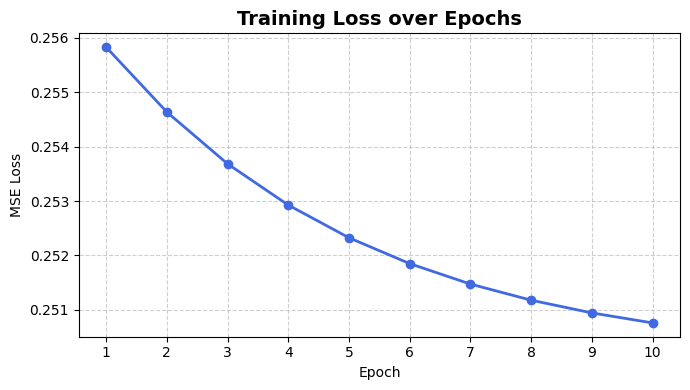


Loss reduced from 0.255830 → 0.250759


In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='royalblue', linewidth=2)
plt.title("Training Loss over Epochs", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"\nLoss reduced from {loss_history[0]:.6f} → {loss_history[-1]:.6f}")


## Step 11 — Final Predictions

In [11]:
print("  Final Predictions vs True Labels")
print("  " + "-" * 40)
print(f"  {'Input':<12} {'Predicted':>10}  {'Rounded':>8}  {'True':>6}")
print("  " + "-" * 40)

_, _, _, final_pred = forward_pass(X, W1, b1, W2, b2)
for i in range(len(X)):
    pred = final_pred[i][0]
    print(f"  {str(X[i]):<12}  {pred:>10.4f}  {round(pred):>8}     {int(y[i][0]):>4}")


  Final Predictions vs True Labels
  ----------------------------------------
  Input         Predicted   Rounded    True
  ----------------------------------------
  [0. 0.]           0.4891         0        0
  [0. 1.]           0.4703         0        1
  [1. 0.]           0.4859         0        1
  [1. 1.]           0.4673         0        0
